In [1]:
!export CUDA_VISIBLE_DEVICES=3


In [2]:
'''
trying to advance to the new dataset (optimised exposure and no grey background)
including jitter runs.
same as rev1 but with a corrected visualisation of the first layer
'''

'\ntrying to advance to the new dataset (optimised exposure and no grey background)\nincluding jitter runs.\nsame as rev1 but with a corrected visualisation of the first layer\n'

In [3]:
# !pip3 install scikit-learn

In [4]:
import os
import sys
sys.path.insert(1, os.getcwd()+'/..')

In [5]:
from eb_train import train
from parser import parser
import eb_train

In [6]:
import shlex

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


In [38]:
import torch
import numpy as np
import random
import pandas as pd


In [9]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

In [10]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook
    
def seed_reset(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)

In [11]:

def prep_model_for_vernier(cmd_line):
    args = parser.parse_args(shlex.split(cmd_line))
    
    io = eb_train._init_(args)
    io.print_and_log(str(args))
    io.print_and_log(f'Dataset args (training): {str(args.ds_args["train"])}')
    io.print_and_log(f'Dataset args (validation): {str(args.ds_args["val"])}')
    
    args.cuda = not args.no_cuda and torch.cuda.is_available()
    
    seed_reset(args.seed)
    
    if args.cuda:
        io.print_and_log(
            'Using GPU : ' + str(torch.cuda.current_device()) + ' from ' + str(torch.cuda.device_count()) + ' devices')
        torch.cuda.manual_seed(args.seed)
    else:
        io.print_and_log('Using CPU')
    
    model, opt, scheduler, criterion, train_loader, val_loader, device, best_val_acc, args_, io_ = train(args, io, prepare_objects_and_return=True)
    _ = model.eval()
    return model, opt, scheduler, criterion, train_loader, val_loader, device, best_val_acc, args_, io_ 


In [12]:
def initiate_hooks(args):
    # for idx,this_layer in enumerate(model.transformer_layers):
    #     this_layer.register_forward_hook(get_activation(idx))
    layers_to_monitor = [model.conv1, model.conv2, model.conv3]
    for idx,this_layer in enumerate(layers_to_monitor):
        this_layer.register_forward_hook(get_activation(idx))
    
    #sham call to model that initiates hooks
    _ = model(torch.tensor(np.zeros([args.batch_size,args.ds_args_n_samples,4]),dtype=torch.float).to(device)
                  )

In [13]:
#here you sometimes need to rerun that next cell manually if an exception is thrown
#this probably has something to do with pytorch parallelism

In [14]:
def calc_activations_etc(train_loader,model,args):
    data_and_activations = {}
    # activations = {} #global dict that will be used to keep activations
    initiate_hooks(args)
    all_logits = []
    all_labels = []
    all_data = []
    all_activns = {k:[] for k in activations}
    for data,labels in train_loader:
        all_data += data
        data  = data.to(device)
        logits = model(data)
        all_logits += logits.cpu().detach().numpy().tolist()
        all_labels += labels.numpy().tolist()
        
        for k in activations:
            all_activns[k] += activations[k].cpu().numpy().tolist()
    
    all_data_np_shaped = np.array(all_data)  
    all_data_np = np.array(all_data).reshape(len(all_data),-1)   
    
    all_labels = np.array(all_labels)
    centered_labels = (all_labels - np.mean(list(set(all_labels))))/(np.max(all_labels)-np.min(all_labels))
    
    all_activns = {k:np.array(these_activns) for k, these_activns in all_activns.items()}
    all_activns_flat = {k:these_activns.reshape([these_activns.shape[0],-1]) for k,these_activns in all_activns.items()}
    return {'all_data_np_shaped':all_data_np_shaped,
            'all_data_np':all_data_np,
            'all_labels':all_labels,
            'centered_labels':centered_labels,
            'all_activns':all_activns,
            'all_activns_flat':all_activns_flat}

In [15]:
#cell 3911



In [16]:
def compute_vernier_accs(all_activns_flat=None,
                         centered_labels=None,
                         layers_to_process=None,
                         all_labels=None,
                         training_labels=None,
                         alpha=None,
                        vernier_idxs=np.arange(7)):      
    all_cat_acs = []
    all_cat_stde = []
    for ll, these_activns in all_activns_flat.items():
        if ll in layers_to_process:
            X_train = these_activns[np.isin(all_labels, training_labels)]
            y_train = centered_labels[np.isin(all_labels, training_labels)]
        #     plt.figure()
            ridge_reg = Ridge(alpha=alpha)  # alpha is the regularization strength
            ridge_reg.fit(X_train, y_train)
            mse_list = []
            cat_acc_list = []
            cat_stde_list = []
            for vernier_idx in vernier_idxs:
                these_labels = [13+vernier_idx,27-vernier_idx]
                X_val = these_activns[np.isin(all_labels,these_labels)]
                y_val = np.sign(centered_labels[np.isin(all_labels,these_labels)])
                mse_list.append(mean_squared_error(ridge_reg.predict(X_val),y_val))
                cat_acc_list.append(np.mean(np.sign(ridge_reg.predict(X_val)) == np.sign(y_val)))
                cat_stde_list.append(1/np.sqrt(len(y_val))* \
                                              np.std(np.sign(ridge_reg.predict(X_val)) == np.sign(y_val)))
            all_cat_acs.append(cat_acc_list)
            all_cat_stde.append(cat_stde_list)
    return all_cat_acs, all_cat_stde

In [17]:


def get_cmd_line(ckpt,jitter):
    # cmd_line = "--run_name=nb_Vernier_rev2_ --config_file ../config/config_hA07det.yaml"+ \
    #     " --model_args_model_head cls_mlp --eb_ds_path /shareds/eb_datasets/20250724/Vernier/"+ \
    #     " --seed 42 --ds_args_n_samples 48 --n_validation 0 --model_args_num_classes 2" + \
    #     (f" --pretrained_model_path ../../checkpoints/{ckpt}//models/last_model.t7" if ckpt is not None else " ") + \
    #     " --model_args_model_head_init_method small_weights --model_args_dropout_rate 0.0" + \
    #     " --disable_data_parallel --en_pretrained_model_no_head" + " --no_ds_args_shuffle_events" + \
    #     f" --ds_train_subdir . --save_path ../saved_runs/  --ds_args_augment_per_event_shifts [{jitters[jj]},0,0,0]"
    
    cmd_line =    "--run_name=try_framebased_Veriner_  --config_file ../config/config_framebased1.yaml"+ \
    " --eb_ds_path /shareds/eb_datasets/20250722/Vernier/"+ \
    " --seed 42 --ds_args_n_samples 48 --n_validation 0 --model_args_num_classes 2" + \
    (f" --pretrained_model_path ../../checkpoints/{ckpt}/models/last_model.t7" if ckpt is not None else ' ') + \
    " --disable_data_parallel --en_pretrained_model_no_head" + " --no_ds_args_shuffle_events" + \
    " --ds_train_subdir . --save_path ../saved_runs/"


    
    cmd_line_with_remap = cmd_line + " --relabel_opt vernier13_27"
    return cmd_line


In [18]:
# ckpt_dirs = ['ebtMNISTD1_20250724_supervised_sweep_115979', None]
#           # 'ebtMNISTD1_20250724_supervised_sweep_115982',
#           # 'ebtMNISTD1_20250724_supervised_sweep_115985',
#           # 'ebtMNISTD1_20250724_supervised_sweep_115988',
#           # 'ebtMNISTD1_20250724_supervised_sweep_115991',
#           #   None]
ckpt_dirs = [f'fbtMNISTD1_supervised_exp6_2_sweep_68447{num}' for num in np.arange(3,8)] + [None]

jitters = [0]
layers_to_process=[0,2]
vernier_idx =0
training_labels = [13+vernier_idx,27-vernier_idx]+\
    [13+vernier_idx+1,27-vernier_idx-1]

alpha = 1
vernier_offsets = 7 - np.arange(7)

all_cat_acs_jtr_mdls = {}
all_cat_stde_jtr_mdls = {}
for jj, jitter in enumerate(jitters):
    all_cat_acs_jtr_mdls[jj], all_cat_stde_jtr_mdls[jj] = [] , []
    for ckpt, ckpt_dir in enumerate(ckpt_dirs):

        #a hook for untrained model
        if jj > 0 and ckpt_dir is None:
            continue #only do the pretrained model for jitter[0] (which should be zero)
        
        cmd_line = get_cmd_line(ckpt_dir,jitter)
        model, opt, scheduler, criterion, train_loader, val_loader, device, best_val_acc, args_, io_  = prep_model_for_vernier(cmd_line)
        top_dict = calc_activations_etc(train_loader,model,args_)
        
        all_cat_acs, all_cat_stde = compute_vernier_accs(all_activns_flat=top_dict['all_activns_flat'],
                                                         centered_labels=top_dict['centered_labels'],
                                                         layers_to_process=layers_to_process,
                                                         all_labels=top_dict['all_labels'],
                                                         training_labels=training_labels,
                                                         alpha=alpha)
        if ckpt_dir is None:
            fresh_acs = all_cat_acs
            fresh_stde = all_cat_stde
        else:
            all_cat_acs_jtr_mdls[jj].append(all_cat_acs)
        # all_cat_stde_jtr_mdls[jj].append(all_cat_stde)
        if jj==0 and ckpt==0:
            base_setting_dict = top_dict


debug args.save_path: ../saved_runs/ args.run_name: try_framebased_Veriner_
debug ds_args:  {'train': {'n_samples': 48, 'shuffle_events': False, 'one_hot_coordinates': False, 'frame_based': True, 'from_time_interval': [70, 180]}, 'val': {'n_samples': 48, 'shuffle_events': False, 'one_hot_coordinates': False, 'frame_based': True, 'start_time': 100}}
Namespace(config_file='../config/config_framebased1.yaml', save_path='../saved_runs/', run_name='try_framebased_Veriner_71', job_id_suffix='', model_args_num_classes=2, eb_ds_path='/shareds/eb_datasets/20250722/Vernier/', ds_train_subdir='.', ds_test_subdir='test', eb_ds_ts_jitter=0.0, ds_args_n_samples=48, ds_args_shuffle_events=False, n_validation=0, use_sgd=False, do_warmup=True, no_cuda=False, seed=42, pretrained_model_path='../../checkpoints/fbtMNISTD1_supervised_exp6_2_sweep_684473/models/last_model.t7', pretrained_model_no_head=True, train_head_only=False, eval=True, flatten_contrastive_input=False, check_job_recovery=False, disable_d

cp: cannot stat '*.py': No such file or directory


load pretrained model from ../../checkpoints/fbtMNISTD1_supervised_exp6_2_sweep_684473/models/last_model.t7 WITHOUT HEAD
missing keys ['conv1.weight', 'conv1.bias', 'conv2.weight', 'conv2.bias', 'conv3.weight', 'conv3.bias', 'fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias']
unexpected keys ['resnet.conv1.weight', 'resnet.bn1.weight', 'resnet.bn1.bias', 'resnet.bn1.running_mean', 'resnet.bn1.running_var', 'resnet.bn1.num_batches_tracked', 'resnet.layer1.0.conv1.weight', 'resnet.layer1.0.bn1.weight', 'resnet.layer1.0.bn1.bias', 'resnet.layer1.0.bn1.running_mean', 'resnet.layer1.0.bn1.running_var', 'resnet.layer1.0.bn1.num_batches_tracked', 'resnet.layer1.0.conv2.weight', 'resnet.layer1.0.bn2.weight', 'resnet.layer1.0.bn2.bias', 'resnet.layer1.0.bn2.running_mean', 'resnet.layer1.0.bn2.running_var', 'resnet.layer1.0.bn2.num_batches_tracked', 'resnet.layer1.1.conv1.weight', 'resnet.layer1.1.bn1.weight', 'resnet.layer1.1.bn1.bias', 'resnet.layer1.1.bn1.running_mean', 'resnet.layer1.1.bn1.r

cp: cannot stat '*.py': No such file or directory


debug args.save_path: ../saved_runs/ args.run_name: try_framebased_Veriner_
debug ds_args:  {'train': {'n_samples': 48, 'shuffle_events': False, 'one_hot_coordinates': False, 'frame_based': True, 'from_time_interval': [70, 180]}, 'val': {'n_samples': 48, 'shuffle_events': False, 'one_hot_coordinates': False, 'frame_based': True, 'start_time': 100}}
Namespace(config_file='../config/config_framebased1.yaml', save_path='../saved_runs/', run_name='try_framebased_Veriner_73', job_id_suffix='', model_args_num_classes=2, eb_ds_path='/shareds/eb_datasets/20250722/Vernier/', ds_train_subdir='.', ds_test_subdir='test', eb_ds_ts_jitter=0.0, ds_args_n_samples=48, ds_args_shuffle_events=False, n_validation=0, use_sgd=False, do_warmup=True, no_cuda=False, seed=42, pretrained_model_path='../../checkpoints/fbtMNISTD1_supervised_exp6_2_sweep_684475/models/last_model.t7', pretrained_model_no_head=True, train_head_only=False, eval=True, flatten_contrastive_input=False, check_job_recovery=False, disable_d

...

cp: cannot stat '*.py': No such file or directory


debug args.save_path: ../saved_runs/ args.run_name: try_framebased_Veriner_
debug ds_args:  {'train': {'n_samples': 48, 'shuffle_events': False, 'one_hot_coordinates': False, 'frame_based': True, 'from_time_interval': [70, 180]}, 'val': {'n_samples': 48, 'shuffle_events': False, 'one_hot_coordinates': False, 'frame_based': True, 'start_time': 100}}
Namespace(config_file='../config/config_framebased1.yaml', save_path='../saved_runs/', run_name='try_framebased_Veriner_75', job_id_suffix='', model_args_num_classes=2, eb_ds_path='/shareds/eb_datasets/20250722/Vernier/', ds_train_subdir='.', ds_test_subdir='test', eb_ds_ts_jitter=0.0, ds_args_n_samples=48, ds_args_shuffle_events=False, n_validation=0, use_sgd=False, do_warmup=True, no_cuda=False, seed=42, pretrained_model_path='../../checkpoints/fbtMNISTD1_supervised_exp6_2_sweep_684477/models/last_model.t7', pretrained_model_no_head=True, train_head_only=False, eval=True, flatten_contrastive_input=False, check_job_recovery=False, disable_d

cp: cannot stat '*.py': No such file or directory


debug args.save_path: ../saved_runs/ args.run_name: try_framebased_Veriner_
debug ds_args:  {'train': {'n_samples': 48, 'shuffle_events': False, 'one_hot_coordinates': False, 'frame_based': True, 'from_time_interval': [70, 180]}, 'val': {'n_samples': 48, 'shuffle_events': False, 'one_hot_coordinates': False, 'frame_based': True, 'start_time': 100}}
Namespace(config_file='../config/config_framebased1.yaml', save_path='../saved_runs/', run_name='try_framebased_Veriner_76', job_id_suffix='', model_args_num_classes=2, eb_ds_path='/shareds/eb_datasets/20250722/Vernier/', ds_train_subdir='.', ds_test_subdir='test', eb_ds_ts_jitter=0.0, ds_args_n_samples=48, ds_args_shuffle_events=False, n_validation=0, use_sgd=False, do_warmup=True, no_cuda=False, seed=42, pretrained_model_no_head=True, train_head_only=False, eval=True, flatten_contrastive_input=False, check_job_recovery=False, disable_data_parallel=True, eb_ds_time_align_by_imu_edge=False, ds_args_one_hot_coordinates=False, en_autodetect_of

cp: cannot stat '*.py': No such file or directory


In [30]:
# import pickle
# with open('vernier_results_rev92_vernier_newDSexperiments_48.pkl','rb') as f:
#     all_cat_acs_jtr_mdls = pickle.load(f)

In [31]:
raw_data_representations={0:base_setting_dict['all_data_np']}
# with open('vernier_results__48.pkl','rb') as f:
#     all_cat_acs_jtr_m

In [32]:
raw_acs, raw_stde = compute_vernier_accs(all_activns_flat=raw_data_representations,
                                                 centered_labels=top_dict['centered_labels'],
                                                 layers_to_process=[0],
                                                 all_labels=top_dict['all_labels'],
                                                 training_labels=training_labels,
                                                 alpha=alpha)

In [33]:
# import pickle
# with open('vernier_Frames.pkl','wb') as f:
#     pickle.dump([all_cat_acs_jtr_mdls,raw_acs,fresh_acs],f)

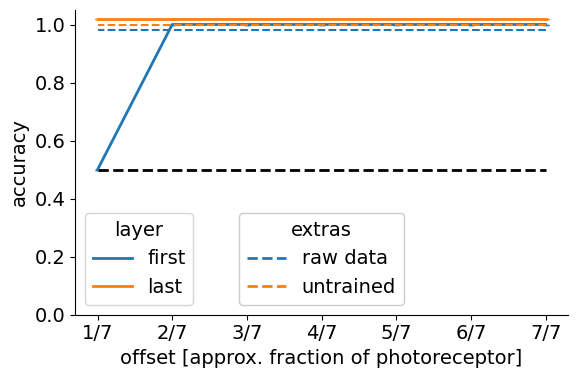

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(1, figsize=(6, 4))
plt.rcParams.update({'font.size': 14})
ax = plt.gca()
rebuttal_addons = True

labels = ['first', 'last']
colors = ['tab:blue', 'tab:orange']
lj = len(jitters)

# --- plot data (no labels here; we'll build legends manually) ---
for ll, _ in enumerate(layers_to_process):
    is_last_layer = (ll == len(layers_to_process) - 1)

    # only sweep jitters for the last layer; otherwise just the first jitter
    jtr_list = jitters if is_last_layer else [jitters[0]]

    for jj, jitter in enumerate(jtr_list):
        xx = np.array(all_cat_acs_jtr_mdls[jj])
        this_data = np.mean(xx, axis=0)[ll]
        this_std  = np.std(xx, axis=0)[ll] / np.sqrt(xx.shape[0])

        alpha = (lj - jj) / lj if is_last_layer else 1.0

        ax.errorbar(
            vernier_offsets, this_data+0.02*ll, this_std,
            color=colors[ll],
            alpha=alpha,
            linewidth=2,
            capsize=2,
        )
        
#enhanced version for referee        
if rebuttal_addons:
    # ax.plot(vernier_offsets,np.array(raw_acs[0])-0.02, color='tab:blue', linestyle='--')
    # ax.plot(vernier_offsets,fresh_acs[1], color='tab:orange', linestyle='--')

    ax.errorbar(vernier_offsets,np.array(raw_acs[0])-0.02,raw_stde[0], color='tab:blue', linestyle='--')
    ax.errorbar(vernier_offsets,fresh_acs[1], fresh_stde[1],color='tab:orange', linestyle='--')
# chance level line
ax.plot([1, 7], [0.5, 0.5], 'k--', linewidth=2)

ax.set_ylabel('accuracy')
ax.set_xlabel('offset [approx. fraction of photoreceptor]')
ax.set_xticks(ticks=np.arange(1,8),labels=[str(ii)+'/7' for ii in range(1,8)])

ax.set_ylim([0, 1.05])
ax.spines[['right', 'top']].set_visible(False)

# --- Legend 1: Layers (colors) ---
layer_handles = [
    Line2D([0], [0], color=c, lw=2, label=lab)
    for lab, c in zip(labels, colors)
]
# layer_handles.append(Line2D([0], [0], color='k', lw=2, ls='--', label='chance level'))
# layer_handles.append(Line2D([0], [0], color='k', lw=2, ls='--'))

leg1 = ax.legend(handles=layer_handles, title='layer', loc='lower left')
ax.add_artist(leg1)  # keep it when adding the second legend

# --- Legend 2: Jitters (alpha) — only meaningful for last layer ---
# jitter_handles = [
#     Line2D([0], [0], color=colors[-1], lw=2, alpha=(lj - jj) / lj, label=str(jtr))
#     for jj, jtr in enumerate(jitters)
# ]
# leg2 = ax.legend(handles=jitter_handles, title='jitter (msec)', loc='lower right', framealpha=1)
# ax.add_artist(leg2) 

if rebuttal_addons:
    rebuttal_handles = [
        Line2D([0], [0], color=c, linestyle='--',lw=2, label=lab)
        for lab, c in zip(['raw data','untrained'], colors)
    ]    
    ax.legend(handles=rebuttal_handles, title='extras', loc='lower center', framealpha=1)

plt.tight_layout()
plt.savefig('figS3panelBottom.svg',format='svg')

plt.show()


In [41]:


# descending offset fractions, matching vernier_offsets = [7,6,5,4,3,2,1]
offset_fractions = [f"{ii}/7" for ii in range(7, 0, -1)]

rows = []

# --- collect main model curves ---
for ll, layer in enumerate(layers_to_process):
    layer_label = labels[ll]  # 'first' / 'last'
    is_last_layer = (ll == len(layers_to_process) - 1)

    # only sweep jitters for the last layer; otherwise just the first jitter
    jtr_list = jitters if is_last_layer else [jitters[0]]

    for jj, jitter in enumerate(jtr_list):
        xx = np.array(all_cat_acs_jtr_mdls[jj])

        this_data = np.mean(xx, axis=0)[ll]
        this_stde = np.std(xx, axis=0)[ll] / np.sqrt(xx.shape[0])

        # match the plotted y-values, including the +0.02*ll shift
        plotted_accuracy = this_data

        for offset_num, offset_frac, acc, stde in zip(
            vernier_offsets,
            offset_fractions,
            plotted_accuracy,
            this_stde
        ):
            rows.append({
                "curve_type": "model",
                "layer": layer_label,
                "jitter": jitter,
                "offset_fraction": offset_frac,
                "offset_numeric": offset_num,
                "accuracy": acc,
                "stde": stde,
            })

# --- collect rebuttal addon curves ---
if rebuttal_addons:
    for offset_num, offset_frac, acc, stde in zip(
        vernier_offsets,
        offset_fractions,
        np.array(raw_acs[0]),
        raw_stde[0]
    ):
        rows.append({
            "curve_type": "raw_data",
            "layer": "first",
            "jitter": np.nan,
            "offset_fraction": offset_frac,
            "offset_numeric": offset_num,
            "accuracy": acc,
            "sem": stde,
        })

    for offset_num, offset_frac, acc, stde in zip(
        vernier_offsets,
        offset_fractions,
        fresh_acs[1],
        fresh_stde[1]
    ):
        rows.append({
            "curve_type": "untrained",
            "layer": "last",
            "jitter": np.nan,
            "offset_fraction": offset_frac,
            "offset_numeric": offset_num,
            "accuracy": acc,
            "sem": stde,
        })

df = pd.DataFrame(rows)

df.to_csv("figS3panelBottom.csv", index=False)

df

,curve_type,layer,jitter,offset_fraction,offset_numeric,accuracy,stde,sem
0,model,first,0.0,7/7,7,1.0,0.0,NaN
1,model,first,0.0,6/7,6,1.0,0.0,NaN
2,model,first,0.0,5/7,5,1.0,0.0,NaN
3,model,first,0.0,4/7,4,1.0,0.0,NaN
4,model,first,0.0,3/7,3,1.0,0.0,NaN
5,model,first,0.0,2/7,2,1.0,0.0,NaN
6,model,first,0.0,1/7,1,0.5,0.0,NaN
7,model,last,0.0,7/7,7,1.0,0.0,NaN
8,model,last,0.0,6/7,6,1.0,0.0,NaN
9,model,last,0.0,5/7,5,1.0,0.0,NaN


In [29]:
ii

2